# Introduction  

Using **Cleaned CICIDS2017 dataset** to train DL models.

In [ ]:
# Importing the relevant libraries

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler, PowerTransformer
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from keras import Sequential, Input
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import json

# Helper Functions

Section to organize some useful functions to further explore and work on the dataset.

In [8]:
def save_results(model, history, y_test, y_pred, model_name):
    """
    Saves model, metrics, confusion matrix, classification report, and plots
    for easy comparison later.
    """

    # 1- Save model
    model.save(f"{model_name}.keras")  # will save in current directory

    # 2- Save metrics (accuracy, precision, recall, etc.)
    with open(f"{model_name}_metrics.json", 'w') as f:
        json.dump(history.history, f, indent=4)

    # 3- Save confusion matrix + classification report
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Normal', 'Malicious'])
    np.save(f"{model_name}_confusion_matrix.npy", cm)
    with open(f"{model_name}_classification_report.txt", 'w') as f:
        f.write(report)

    print(f"All results for {model_name} saved successfully")

In [9]:
def compare_models(model_names):
    results = {}

    for name in model_names:
        # --- Load saved metrics ---
        with open(f"{name}_metrics.json", "r") as f:
            metrics = json.load(f)
        cm = np.load(f"{name}_confusion_matrix.npy")

        # --- Load classification report (as plain text) ---
        with open(f"{name}_classification_report.txt", "r") as f:
            report = f.read()

        results[name] = {
            "metrics": metrics,
            "confusion_matrix": cm,
            "classification_report": report
        }

    # --- Plot metrics ---
    plt.figure(figsize=(14, 5))
    metric_list = ['accuracy', 'precision', 'recall', 'loss']

    for i, metric in enumerate(metric_list):
        plt.subplot(1, len(metric_list), i + 1)
        for name in model_names:
            if metric in results[name]['metrics']:
                plt.plot(results[name]['metrics'][metric], label=f"{name} Train")
            if f"val_{metric}" in results[name]['metrics']:
                plt.plot(results[name]['metrics'][f"val_{metric}"], '--', label=f"{name} Val")
        plt.title(metric.capitalize())
        plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Confusion matrices ---
    for name in model_names:
        cm = results[name]['confusion_matrix']
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {name}")
        plt.show()

    # --- Summary stats ---
    print("\nFinal Validation Scores:")
    for name in model_names:
        metrics = results[name]['metrics']
        print(f"\nModel: {name}")
        for metric in metric_list:
            val_key = f"val_{metric}"
            if val_key in metrics:
                print(f"  {metric.capitalize()}: {metrics[val_key][-1]:.4f}")

    # --- Classification Reports ---
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORTS")
    print("=" * 60)
    for name in model_names:
        print(f"\nModel: {name}")
        print(results[name]["classification_report"])
        print("-" * 60)

    # --- Clean up temporary variables ---
    del metrics, cm, report, name, i, metric, val_key
    del metric_list, disp, results

In [10]:
def evaluate_realtime_performance(models_dict, test_data, sample_size=10000):
    """
    Combined function to benchmark Latency, PPS, and Mbps for multiple models.
    Supports both NumPy arrays and Pandas DataFrames for size calculation.
    """
    performance_summary = []
    
    # 1. Calculate Average Record Size (in Bytes)
    if isinstance(test_data, pd.DataFrame):
        avg_record_size = test_data.memory_usage(deep=True).sum() / len(test_data)
    else:
        # For NumPy arrays: (total bytes / number of samples)
        # This represents the size of one sequence/record in memory
        avg_record_size = test_data.nbytes / test_data.shape[0]

    # Prepare sample for benchmarking
    test_sample = test_data[:sample_size]
    
    print(f"{'Model Name':<20} | {'Latency (ms)':<15} | {'PPS':<12} | {'Throughput (Mbps)':<15}")
    print("-" * 75)

    for name, model in models_dict.items():
        # Warm-up (Important for accurate GPU/CPU timing)
        _ = model.predict(test_sample[:1], verbose=0)
        
        # Measure Latency
        start_time = time.perf_counter()
        _ = model.predict(test_sample, verbose=0)
        end_time = time.perf_counter()
        
        # Calculations
        total_time_ms = (end_time - start_time) * 1000
        avg_latency = total_time_ms / sample_size
        pps = 1000 / avg_latency
        throughput_mbps = (pps * avg_record_size * 8) / 1_000_000
        
        performance_summary.append({
            'Model': name,
            'Latency': avg_latency,
            'PPS': pps,
            'Mbps': throughput_mbps
        })
        
        print(f"{name:<20} | {avg_latency:<15.6f} | {pps:<12.2f} | {throughput_mbps:<15.2f}")

    # Find the best model based on Latency
    best_model = min(performance_summary, key=lambda x: x['Latency'])
    
    print("-" * 75)
    print(f"Optimal Real-Time Model: {best_model['Model']}")
    print(f"Max Supported Bandwidth: {best_model['Mbps']:.2f} Mbps")
    
    return performance_summary

In [11]:
def find_unanimous_useless_features(models_dict, X, y, feature_names, sample_size=500):
    """
    Computes permutation importance for all models and identifies features 
    that have zero or negative importance across ALL architectures.
    """
    X_sample = X[:sample_size]
    y_sample = y[:sample_size]
    
    all_importances = pd.DataFrame(index=feature_names)
    
    for name, model in models_dict.items():
        print(f"Analyzing Model: {name}...")
        
        # Baseline Accuracy
        baseline_acc = model.evaluate(X_sample, y_sample, verbose=0)[1]
        importances = []
        
        for i in range(X.shape[2]):
            X_permuted = X_sample.copy()
            np.random.shuffle(X_permuted[:, :, i])
            
            permuted_acc = model.evaluate(X_permuted, y_sample, verbose=0)[1]
            importances.append(baseline_acc - permuted_acc)
            
        all_importances[name] = importances

    # Find features where importance <= 0 for EVERY model in the dictionary
    # We use a very small threshold (1e-5) to account for floating point noise
    useless_mask = (all_importances <= 1e-5).all(axis=1)
    useless_features = all_importances[useless_mask].index.tolist()
    
    print(f"\n--- Analysis Complete ---")
    print(f"Total features analyzed: {len(feature_names)}")
    print(f"Unanimous 'Zero-Importance' features found: {len(useless_features)}")
    
    return all_importances, useless_features

# 1. DL Models

In [355]:
# --- Step 1: Feature Engineering & Scaling ---
target = 'Attack Type'
train_df = pd.read_csv("train_data.csv")
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X = train_df.drop(columns=target).values
y = train_df[target].values
X_scaled = scaler.fit_transform(X)

In [356]:
# --- Step 2: Sequence Preparation ---
# Fixed sequence reshaping to ensure data integrity
timesteps = 10 
num_samples = len(X_scaled) // timesteps
X_seq = X_scaled[:num_samples * timesteps].reshape(num_samples, timesteps, -1)
y_seq = y[:num_samples * timesteps:timesteps] 

# --- Step 3: Data Splitting ---
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights_dict = dict(enumerate(weights))

# --- Step 4: Class Weights Calculation & SMOTE for 3D Data ---
# Balancing the classes to prevent the model from favoring 'Normal' traffic
# SMOTE requires 2D input, so we flatten, resample, and then reshape back to 3D
n_samples, n_timesteps, n_features = X_train.shape
X_train_2d = X_train.reshape(n_samples, n_timesteps * n_features)

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_resampled_2d, y_resampled = smote.fit_resample(X_train_2d, y_train)

# Reshaping back to 3D for LSTM/CNN models
X_resampled = X_resampled_2d.reshape(X_resampled_2d.shape[0], n_timesteps, n_features)

## 1.1 RNN Model

In [94]:
# --- Step 5: Build Optimized RNN Model ---
model = Sequential([

    Input(shape=(timesteps, X_train.shape[2])),  

    # First RNN layer: return_sequences=True to pass data to the next RNN layer
    SimpleRNN(128, activation='tanh', return_sequences=True), 
    Dropout(0.2),

    # Second RNN layer: return_sequences=True to stack the third layer
    SimpleRNN(128, activation='tanh', return_sequences=True), 
    Dropout(0.2),

    # Third RNN layer: return_sequences=False to provide the final hidden state
    SimpleRNN(128, activation='tanh', return_sequences=False), 
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')

])

In [95]:
# --- Step 6: Compilation ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy', 
        tf.keras.metrics.Precision(name='precision'), 
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [96]:
# --- Step 7: Training Configuration ---
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_resampled, y_resampled,
    epochs=20,  
    batch_size=2048,
    validation_split=0.2,
    # class_weight=class_weight_dict,  # Handles class imbalance
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 10, 128)             │          21,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 10, 128)             │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,713 (358.25 KB)

 Trainable params: 91,713 (358.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.6645 - loss: 0.6057 - precision: 0.6638 - recall: 0.2135 - val_accuracy: 0.9558 - val_loss: 0.1858 - val_precision: 1.0000 - val_recall: 0.9558
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.9543 - loss: 0.1418 - precision: 0.9445 - recall: 0.9329 - val_accuracy: 0.9785 - val_loss: 0.0624 - val_precision: 1.0000 - val_recall: 0.9785
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.9701 - loss: 0.0884 - precision: 0.9709 - recall: 0.9486 - val_accuracy: 0.9892 - val_loss: 0.0308 - val_precision: 1.0000 - val_recall: 0.9892
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.9748 - loss: 0.0745 - precision: 0.9774 - recall: 0.9549 - val_accuracy: 0.9759 - val_loss: 0.0596 - val_precision: 1.0000 - val_recall: 0.9759
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - accuracy: 0.9763 - loss: 0.0683 - precision: 0.9783 - recall: 0.9580 - val_accuracy: 0.9817 - val_los

In [97]:
# Step 8: Evaluate the Model
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Threshold at 0.5 for binary classification

787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [98]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     20845
   Malicious       0.86      0.99      0.92      4334

    accuracy                           0.97     25179
   macro avg       0.93      0.98      0.95     25179
weighted avg       0.97      0.97      0.97     25179



Text(0.5, 1.0, 'Recall')

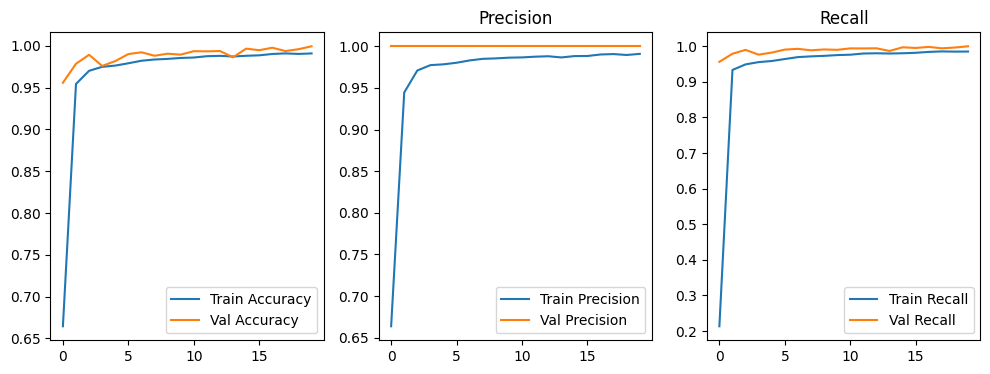

In [99]:
# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
# plt.title('Accuracy')
plt.savefig('RNN Accuracy.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

plt.subplot(1, 3, 2)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.legend()
plt.title('Precision')

plt.subplot(1, 3, 3)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.legend()
plt.title('Recall')

In [100]:
save_results(model, history, y_test, y_pred, model_name="RNN_model")

All results for RNN_model saved successfully


## 1.2 CNN Model

In [101]:
# --- Step 5: Build Optimized CNN-1D Architecture ---
model_cnn = Sequential([
    Input(shape=(timesteps, X_train.shape[2])),

    # Layer 1: Initial feature extraction
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Layer 2: Deeper pattern recognition
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    # Note: Pooling is skipped here if the sequence length (timesteps) is too small
    Dropout(0.3),

    # Layer 3: Complex temporal-spatial features
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    # Transition to Dense Layers
    Flatten(),

    # Decision Making Block
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    
    # Binary Classification Output
    Dense(1, activation='sigmoid')
])

In [102]:
# --- Step 6: Compilation ---
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# --- Step 7: Training Setup ---
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_resampled, y_resampled,
    epochs=20,
    batch_size=2048,
    validation_split=0.2,
    # class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.8443 - loss: 0.3390 - precision: 0.8100 - recall: 0.7640 - val_accuracy: 0.7453 - val_loss: 0.5735 - val_precision: 1.0000 - val_recall: 0.7453
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step - accuracy: 0.9554 - loss: 0.1262 - precision: 0.9563 - recall: 0.9232 - val_accuracy: 0.9231 - val_loss: 0.1600 - val_precision: 1.0000 - val_recall: 0.9231
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 217ms/step - accuracy: 0.9662 - loss: 0.0972 - precision: 0.9690 - recall: 0.9400 - val_accuracy: 0.9673 - val_loss: 0.0671 - val_precision: 1.0000 - val_recall: 0.9673
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 206ms/step - accuracy: 0.9711 - loss: 0.0828 - precision: 0.9729 - recall: 0.9493 - val_accuracy: 0.9859 - val_loss: 0.0327 - val_precision: 1.0000 - val_recall: 0.9859
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - accuracy: 0.9744 - loss: 0.0738 - precision: 0.9766 - recall: 0.9546 - val_accuracy: 0.9863 - val_los

In [103]:
# Step 8: Evaluate the Model
# Predict on test set
y_pred_prob = model_cnn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Threshold at 0.5 for binary classification

787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [104]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     20845
   Malicious       0.93      0.97      0.95      4334

    accuracy                           0.98     25179
   macro avg       0.96      0.98      0.97     25179
weighted avg       0.98      0.98      0.98     25179



Text(0.5, 1.0, 'Recall')

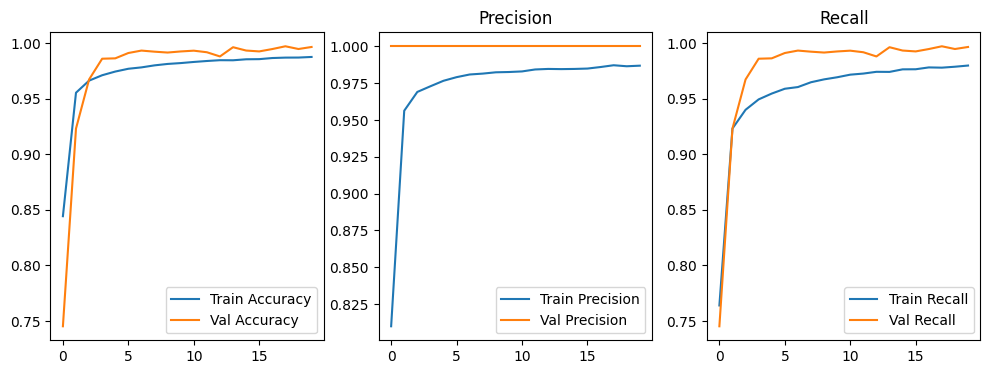

In [105]:
# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.legend()
# plt.title('Accuracy')
plt.savefig('CNN Accuracy.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

plt.subplot(1, 3, 2)
plt.plot(history_cnn.history['precision'], label='Train Precision')
plt.plot(history_cnn.history['val_precision'], label='Val Precision')
plt.legend()
plt.title('Precision')

plt.subplot(1, 3, 3)
plt.plot(history_cnn.history['recall'], label='Train Recall')
plt.plot(history_cnn.history['val_recall'], label='Val Recall')
plt.legend()
plt.title('Recall')

In [106]:
save_results(model_cnn, history_cnn, y_test, y_pred, model_name="CNN_model")

All results for CNN_model saved successfully


## 1.3 LSTM Model

In [107]:
# --- Step 5: 3-Layer LSTM Architecture ---
model_lstm = Sequential([
    Input(shape=(timesteps, X_train.shape[2])),

    # Layer 1: High-capacity LSTM to capture initial temporal features
    LSTM(128, return_sequences=True), 
    BatchNormalization(),
    Dropout(0.5),

    # Layer 2: Intermediate LSTM to process complex sequences
    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.5),

    # Layer 3: Final LSTM layer (return_sequences=False to condense output)
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.5),

    # Fully Connected block for final classification logic
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    
    # Final Sigmoid layer for Binary Classification
    Dense(1, activation='sigmoid')
])

In [108]:
# --- Step 6: Compilation ---
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# --- Step 7: Training Setup ---
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_resampled, y_resampled,
    epochs=20,
    batch_size=2048,
    validation_split=0.2,
    # class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 809ms/step - accuracy: 0.7825 - loss: 0.4660 - precision: 0.7256 - recall: 0.6754 - val_accuracy: 0.9993 - val_loss: 0.0479 - val_precision: 1.0000 - val_recall: 0.9993
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 739ms/step - accuracy: 0.9661 - loss: 0.1107 - precision: 0.9676 - recall: 0.9411 - val_accuracy: 0.9924 - val_loss: 0.0254 - val_precision: 1.0000 - val_recall: 0.9924
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 746ms/step - accuracy: 0.9744 - loss: 0.0817 - precision: 0.9785 - recall: 0.9527 - val_accuracy: 0.9887 - val_loss: 0.0257 - val_precision: 1.0000 - val_recall: 0.9887
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 806ms/step - accuracy: 0.9783 - loss: 0.0671 - precision: 0.9805 - recall: 0.9613 - val_accuracy: 0.9918 - val_loss: 0.0194 - val_precision: 1.0000 - val_recall: 0.9918
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 794ms/step - accuracy: 0.9817 - loss: 0.0575 - precision: 0.9835 - recall: 0.9674 - val_accuracy: 0.9944 - val_los

In [109]:
# Step 8: Evaluate the Model
# Predict on test set
y_pred_prob = model_lstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Threshold at 0.5 for binary classification

787/787 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step


In [110]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     20845
   Malicious       0.90      0.98      0.94      4334

    accuracy                           0.98     25179
   macro avg       0.95      0.98      0.96     25179
weighted avg       0.98      0.98      0.98     25179



Text(0.5, 1.0, 'Recall')

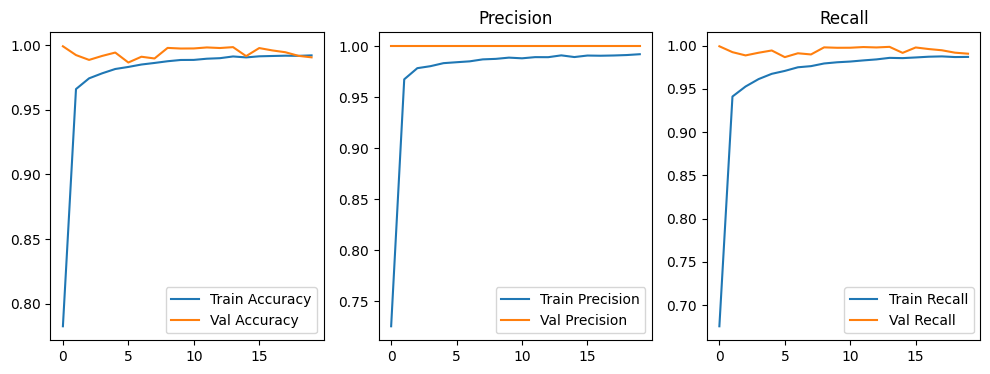

In [111]:
# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.legend()
# plt.title('Accuracy')
plt.savefig('LSTM Accuracy.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['precision'], label='Train Precision')
plt.plot(history_lstm.history['val_precision'], label='Val Precision')
plt.legend()
plt.title('Precision')

plt.subplot(1, 3, 3)
plt.plot(history_lstm.history['recall'], label='Train Recall')
plt.plot(history_lstm.history['val_recall'], label='Val Recall')
plt.legend()
plt.title('Recall')

In [112]:
save_results(model_lstm, history_lstm, y_test, y_pred, model_name="LSTM_model")

All results for LSTM_model saved successfully


## 1.4 CNN-LSTM Model

In [113]:
# --- Step 5: 
model_hybrid = Sequential([
    Input(shape=(timesteps, X_train.shape[2])),
    
    # 1st Layer: CNN (Pattern Extraction)
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    
    # 2nd Layer: LSTM (First Sequence Learning)
    # return_sequences=True is necessary to pass data to the next LSTM layer
    LSTM(128, return_sequences=True), 
    Dropout(0.3),
    
    # 3rd Layer: LSTM (Final Sequence Learning)
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    
    # Classification Head
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [114]:
# --- Step 6: Compilation ---
model_hybrid.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# --- Step 7: Training Setup ---
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_hybrid = model_hybrid.fit(
    X_resampled, y_resampled,
    epochs=20,
    batch_size=2048,
    validation_split=0.2,
    # class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.8287 - loss: 0.3687 - precision: 0.8108 - recall: 0.7086 - val_accuracy: 0.0000e+00 - val_loss: 6.0797 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9546 - loss: 0.1300 - precision: 0.9572 - recall: 0.9201 - val_accuracy: 5.3968e-04 - val_loss: 4.9859 - val_precision: 1.0000 - val_recall: 5.3968e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.9660 - loss: 0.1007 - precision: 0.9695 - recall: 0.9388 - val_accuracy: 0.3090 - val_loss: 1.9911 - val_precision: 1.0000 - val_recall: 0.3090
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9711 - loss: 0.0857 - precision: 0.9746 - recall: 0.9477 - val_accuracy: 0.7112 - val_loss: 0.7003 - val_precision: 1.0000 - val_recall: 0.7112
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.9741 - loss: 0.0763 - precision: 0.9788 - recall: 0.9514 - val_accuracy

In [115]:
# Step 8: Evaluate the Model
# Predict on test set
y_pred_prob = model_hybrid.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Threshold at 0.5 for binary classification

787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [116]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97     20845
   Malicious       0.83      0.93      0.88      4334

    accuracy                           0.95     25179
   macro avg       0.91      0.95      0.92     25179
weighted avg       0.96      0.95      0.96     25179



Text(0.5, 1.0, 'Recall')

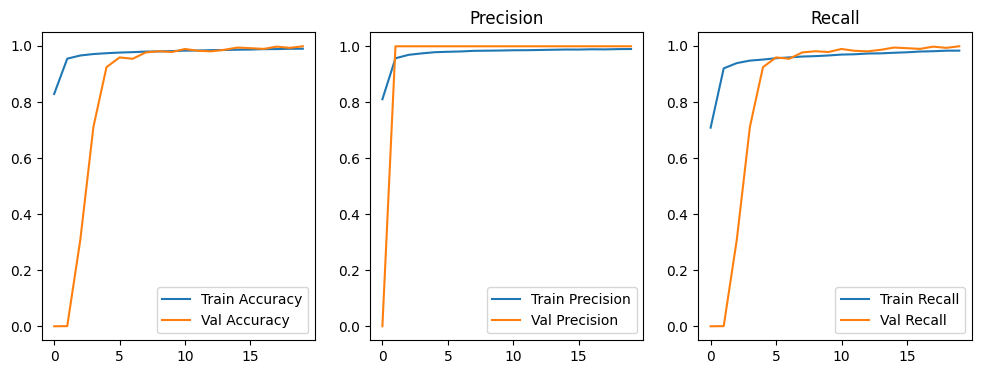

In [117]:
# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history_hybrid.history['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid.history['val_accuracy'], label='Val Accuracy')
plt.legend()
# plt.title('Accuracy')
plt.savefig('Hybrid Accuracy.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

plt.subplot(1, 3, 2)
plt.plot(history_hybrid.history['precision'], label='Train Precision')
plt.plot(history_hybrid.history['val_precision'], label='Val Precision')
plt.legend()
plt.title('Precision')

plt.subplot(1, 3, 3)
plt.plot(history_hybrid.history['recall'], label='Train Recall')
plt.plot(history_hybrid.history['val_recall'], label='Val Recall')
plt.legend()
plt.title('Recall')

In [118]:
save_results(model_hybrid, history_hybrid, y_test, y_pred, model_name="CNN-LSTM_model")

All results for CNN-LSTM_model saved successfully


## 1.5 GRU Model

In [357]:
# --- Step 5: 
model_gru = Sequential([
    Input(shape=(timesteps, X_train.shape[2])),
    
    GRU(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.5),
    
    GRU(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [358]:
# --- Step 6: Compilation ---
model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# --- Step 7: Training Setup ---
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_gru = model_gru.fit(
    X_resampled, y_resampled,
    epochs=20,
    batch_size=2048,
    validation_split=0.2,
    # class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 38s 413ms/step - accuracy: 0.8122 - loss: 0.3829 - precision: 0.7756 - recall: 0.7026 - val_accuracy: 0.9848 - val_loss: 0.0821 - val_precision: 1.0000 - val_recall: 0.9848
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 27s 363ms/step - accuracy: 0.9492 - loss: 0.1290 - precision: 0.9423 - recall: 0.9211 - val_accuracy: 0.9461 - val_loss: 0.1280 - val_precision: 1.0000 - val_recall: 0.9461
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 416ms/step - accuracy: 0.9625 - loss: 0.0961 - precision: 0.9568 - recall: 0.9427 - val_accuracy: 0.9735 - val_loss: 0.0695 - val_precision: 1.0000 - val_recall: 0.9735
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 430ms/step - accuracy: 0.9702 - loss: 0.0790 - precision: 0.9648 - recall: 0.9554 - val_accuracy: 0.9633 - val_loss: 0.0945 - val_precision: 1.0000 - val_recall: 0.9633
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 25s 343ms/step - accuracy: 0.9751 - loss: 0.0670 - precision: 0.9704 - recall: 0.9630 - val_accuracy: 0.9515 - val_los

In [340]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     20893
   Malicious       0.97      0.98      0.97      4258

    accuracy                           0.99     25151
   macro avg       0.98      0.99      0.98     25151
weighted avg       0.99      0.99      0.99     25151



Text(0.5, 1.0, 'Recall')

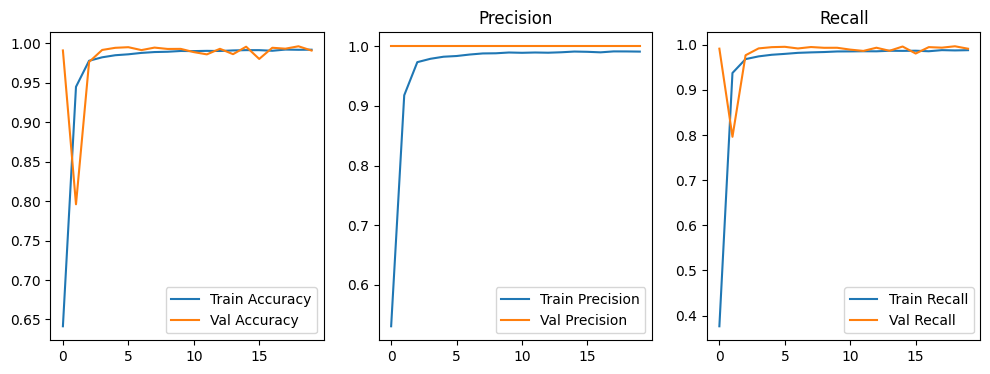

In [294]:
# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Val Accuracy')
plt.legend()
# plt.title('Accuracy')
plt.savefig('GRU Accuracy.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

plt.subplot(1, 3, 2)
plt.plot(history_gru.history['precision'], label='Train Precision')
plt.plot(history_gru.history['val_precision'], label='Val Precision')
plt.legend()
plt.title('Precision')

plt.subplot(1, 3, 3)
plt.plot(history_gru.history['recall'], label='Train Recall')
plt.plot(history_gru.history['val_recall'], label='Val Recall')
plt.legend()
plt.title('Recall')

In [295]:
save_results(model_gru, history_gru, y_test, y_pred, model_name="GRU_model")

All results for GRU_model saved successfully


## 1.6. ANN

In [180]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Flatten

# --- الخطوة 2: بناء هيكل الـ ANN المعدل ---
model_ann = Sequential([
    # هنا بنقول للموديل إنه هيستلم (10 خطوات زمنية × 41 ميزة)
    Input(shape=(X_train.shape[1], X_train.shape[2])), 
    
    # الطبقة دي هي اللي هتحل المشكلة: بتحول الـ (10, 41) لـ 410 سطر واحد
    Flatten(), 
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model_ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# --- الخطوة 3: التدريب ---
print(f"Shape of X_train going into Flatten: {X_train.shape}") # للتأكد: مفروض (None, 10, 41)

model_ann.fit(
    X_train, y_train,
    epochs=15,
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

Shape of X_train going into Flatten: (100716, 10, 41)
Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8398 - loss: 0.3712 - recall: 0.4131 - val_accuracy: 0.9363 - val_loss: 0.1766 - val_recall: 0.7527
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9464 - loss: 0.1552 - recall: 0.7929 - val_accuracy: 0.9664 - val_loss: 0.1105 - val_recall: 0.8483
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9642 - loss: 0.1121 - recall: 0.8552 - val_accuracy: 0.9712 - val_loss: 0.0934 - val_recall: 0.8731
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9691 - loss: 0.0959 - recall: 0.8712 - val_accuracy: 0.9701 - val_loss: 0.0902 - val_recall: 0.8964
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9720 - loss: 0.0874 - recall: 0.8798 - val_accuracy: 0.9743 - val_loss: 0.0794 - val_recall: 0.8880
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9738 - loss: 0.0809 - recall: 0.8861 - val_accuracy: 0.9

In [184]:
# Print classification report
y_pred_prob = model_gru.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Threshold at 0.5 for binary classification
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     20845
   Malicious       0.93      0.98      0.95      4334

    accuracy                           0.98     25179
   macro avg       0.96      0.98      0.97     25179
weighted avg       0.98      0.98      0.98     25179



## 1.7. Hybrid

In [278]:
model_smart = Sequential([
    Input(shape=(10, 22)), # الـ 22 عمود بتوعك
    
    # استخدام Bidirectional GRU بيخلي الموديل يقرأ الداتا من قدام لورا والعكس
    # وده بيخليه يفهم سياق الهجوم أحسن بكتير
    Bidirectional(GRU(64, return_sequences=False)),
    
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model_smart.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# --- الخطوة 3: التدريب ---
print(f"Shape of X_train going into Flatten: {X_train.shape}") # للتأكد: مفروض (None, 10, 41)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_smart.fit(
    X_resampled, y_resampled,
    epochs=20,
    batch_size=2048,
    validation_split=0.2,
    # class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

Shape of X_train going into Flatten: (100603, 10, 22)
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.8607 - loss: 0.3273 - recall: 0.7453 - val_accuracy: 0.9610 - val_loss: 0.1254 - val_recall: 0.9610
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.9672 - loss: 0.1003 - recall: 0.9560 - val_accuracy: 0.9803 - val_loss: 0.0671 - val_recall: 0.9803
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.9780 - loss: 0.0682 - recall: 0.9710 - val_accuracy: 0.9865 - val_loss: 0.0469 - val_recall: 0.9865
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.9820 - loss: 0.0547 - recall: 0.9759 - val_accuracy: 0.9880 - val_loss: 0.0380 - val_recall: 0.9880
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 162ms/step - accuracy: 0.9857 - loss: 0.0443 - recall: 0.9799 - val_accuracy: 0.9912 - val_loss: 0.0288 - val_recall: 0.9912
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9875 - loss: 0.0392 - recall: 0.9819 - val_a

In [279]:
y_pred_prob = model_smart.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) 

786/786 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [280]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     20893
   Malicious       0.96      0.98      0.97      4258

    accuracy                           0.99     25151
   macro avg       0.98      0.99      0.98     25151
weighted avg       0.99      0.99      0.99     25151



# 2. Models Comparison

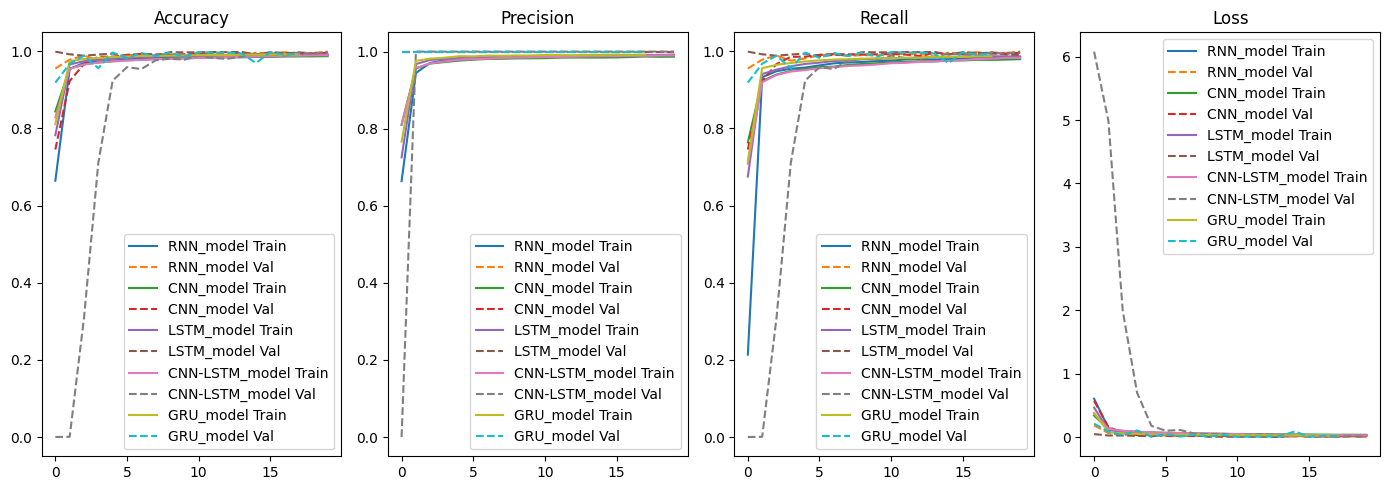

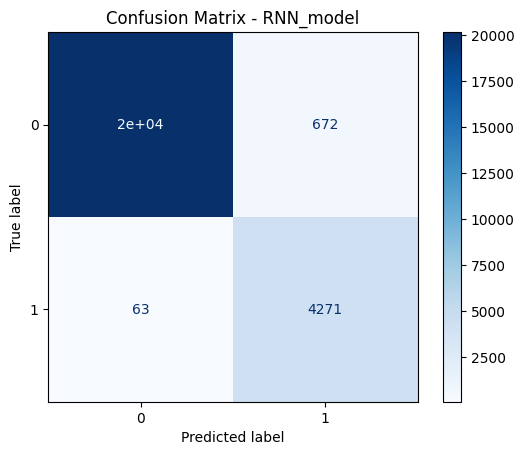

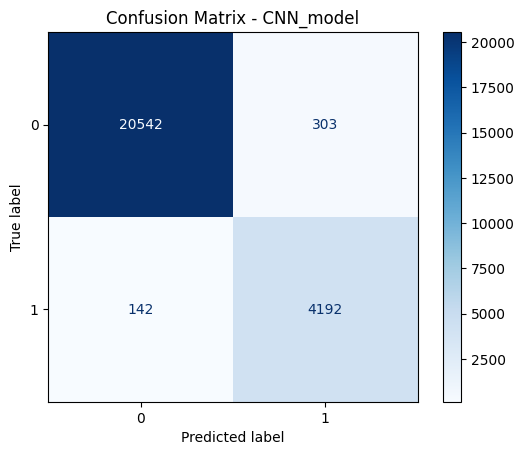

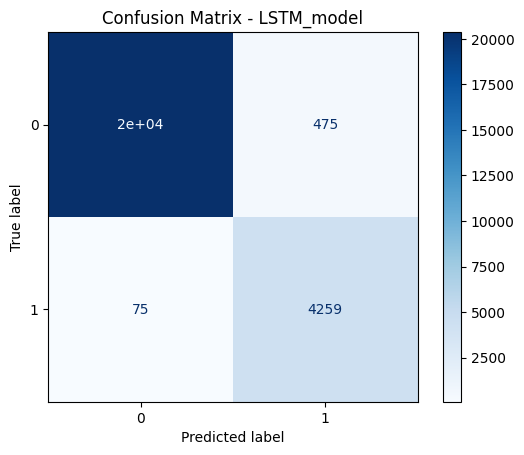

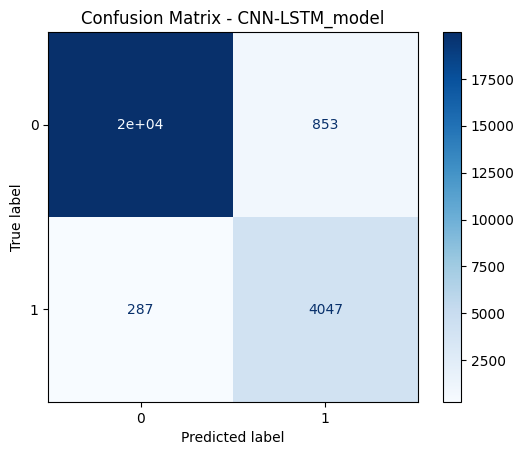

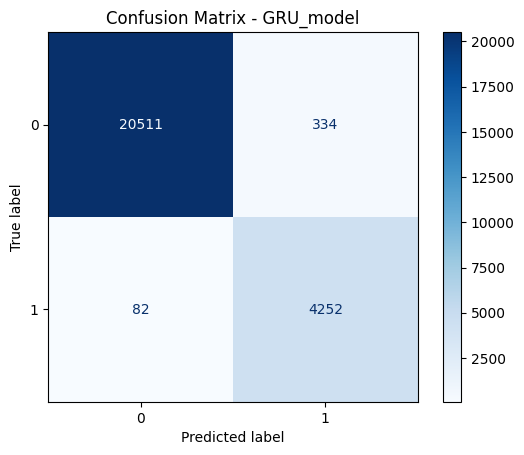


Final Validation Scores:

Model: RNN_model
  Accuracy: 0.9994
  Precision: 1.0000
  Recall: 0.9994
  Loss: 0.0017

Model: CNN_model
  Accuracy: 0.9965
  Precision: 1.0000
  Recall: 0.9965
  Loss: 0.0094

Model: LSTM_model
  Accuracy: 0.9907
  Precision: 1.0000
  Recall: 0.9907
  Loss: 0.0252

Model: CNN-LSTM_model
  Accuracy: 0.9988
  Precision: 1.0000
  Recall: 0.9988
  Loss: 0.0047

Model: GRU_model
  Accuracy: 0.9935
  Precision: 1.0000
  Recall: 0.9935
  Loss: 0.0164

CLASSIFICATION REPORTS

Model: RNN_model
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     20845
   Malicious       0.86      0.99      0.92      4334

    accuracy                           0.97     25179
   macro avg       0.93      0.98      0.95     25179
weighted avg       0.97      0.97      0.97     25179

------------------------------------------------------------

Model: CNN_model
              precision    recall  f1-score   support

      Normal       0

In [125]:
compare_models(["RNN_model", "CNN_model", "LSTM_model", "CNN-LSTM_model", "GRU_model"])

In [126]:
models_to_test = {
    "RNN": model,
    "CNN": model_cnn,
    "LSTM": model_lstm,
    "GRU": model_gru,
    "CNN_LSTM_Hybrid": model_hybrid
}

performance_results = evaluate_realtime_performance(models_to_test, X_test)

Model Name           | Latency (ms)    | PPS          | Throughput (Mbps)
---------------------------------------------------------------------------
RNN                  | 0.141899        | 7047.27      | 184.92         
CNN                  | 0.139993        | 7143.24      | 187.44         
LSTM                 | 0.349914        | 2857.85      | 74.99          
GRU                  | 0.189239        | 5284.32      | 138.66         
CNN_LSTM_Hybrid      | 0.129958        | 7694.78      | 201.91         
---------------------------------------------------------------------------
Optimal Real-Time Model: CNN_LSTM_Hybrid
Max Supported Bandwidth: 201.91 Mbps


# 3. XAI

In [129]:
feature_names = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance',
       'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Down/Up Ratio', 'Active Mean', 'Active Std', 'Active Max',
       'Active Min', 'Idle Mean', 'Idle Std']

In [133]:
def check_gru_logic(model, X_test, y_test, feature_names):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    baseline_f1 = f1_score(y_test, y_pred)
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
    
    importances = []
    
    for i in range(len(feature_names)):
        save_feature = X_test[:, :, i].copy()
        
        for t in range(X_test.shape[1]):
            np.random.shuffle(X_test[:, t, i])
        
        y_pred_shuffled = (model.predict(X_test) > 0.5).astype(int)
        shuffled_f1 = f1_score(y_test, y_pred_shuffled)
        
        importances.append(baseline_f1 - shuffled_f1)
        X_test[:, :, i] = save_feature
        
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    return importance_df.sort_values(by='Importance', ascending=False)

importance_results = check_gru_logic(model_gru, X_test, y_test, feature_names)
print(importance_results.head(10))

787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Baseline F1-Score: 0.9534
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 4s

  0%|          | 0/10 [00:00<?, ?it/s]

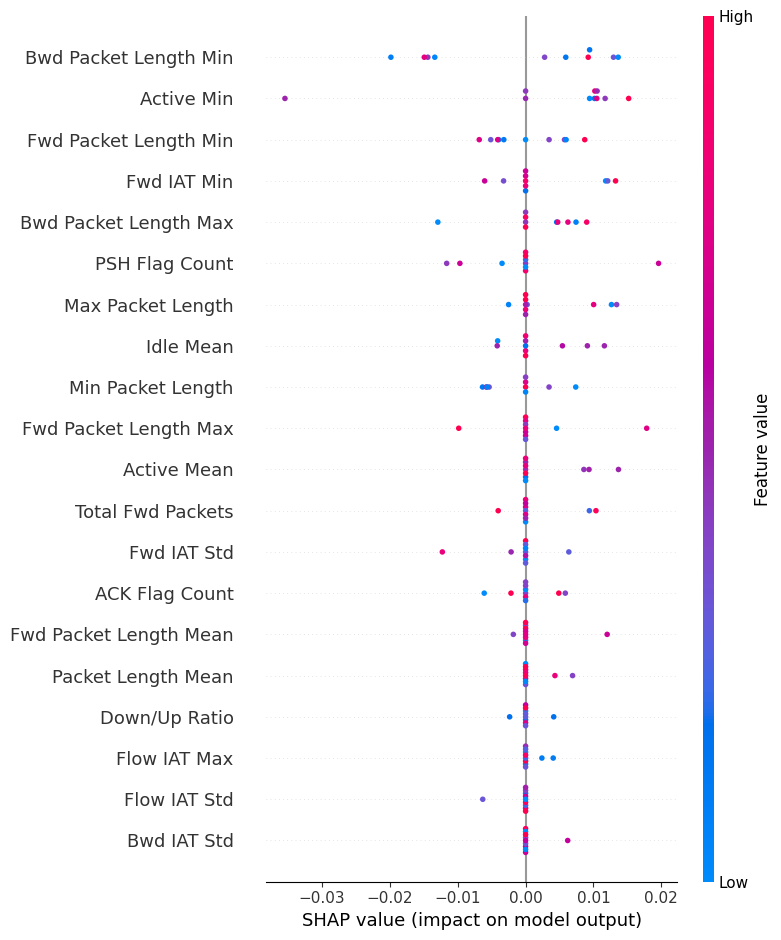

In [ ]:
import shap

background = X_train[np.random.choice(X_train.shape[0], 20, replace=False)]
test_samples = X_test[np.random.choice(X_test.shape[0], 10, replace=False)]

def predict_fn(x):
    x_reshaped = x.reshape(-1, timesteps, X_train.shape[2])
    return model_gru.predict(x_reshaped, verbose=0).flatten()

background_2d = background.reshape(background.shape[0], -1)
test_samples_2d = test_samples.reshape(test_samples.shape[0], -1)

explainer = shap.KernelExplainer(predict_fn, background_2d)

shap_values = explainer.shap_values(test_samples_2d)


shap_vals_array = np.array(shap_values)
if len(shap_vals_array.shape) > 2:
    shap_vals_array = shap_vals_array[0]

shap_values_3d = shap_vals_array.reshape(-1, timesteps, X_train.shape[2])
shap_values_final = np.mean(shap_values_3d, axis=1) 
test_samples_final = np.mean(test_samples, axis=1) 

shap.summary_plot(shap_values_final, test_samples_final, feature_names=feature_names)

In [ ]:
mean_shap_values = np.abs(shap_values_final).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP_Value': mean_shap_values
})

shap_importance_df = shap_importance_df.sort_values(by='Mean_SHAP_Value', ascending=False)

print("--- SHAP Numerical Importance (Top 10) ---")
print(shap_importance_df.head(10))

--- SHAP Numerical Importance (Top 10) ---
                  Feature  Mean_SHAP_Value
8   Bwd Packet Length Min         0.011653
38             Active Min         0.011317
5   Fwd Packet Length Min         0.004712
18            Fwd IAT Min         0.004643
7   Bwd Packet Length Max         0.004491
31         PSH Flag Count         0.004437
27      Max Packet Length         0.003882
39              Idle Mean         0.003444
26      Min Packet Length         0.003403
4   Fwd Packet Length Max         0.003226


In [136]:
def analyze_boundary(model, sample, feature_index, feature_name):
    modified_sample = sample.copy().reshape(1, timesteps, -1)
    
    print(f"--- Testing Boundary for: {feature_name} ---")
    
    original_val = modified_sample[0, :, feature_index].mean()
    for scale in np.linspace(1.0, 0.0, 10):
        modified_sample[0, :, feature_index] = original_val * scale
        prediction = model.predict(modified_sample, verbose=0)[0][0]
        label = "Malicious" if prediction > 0.5 else "Normal"
        print(f"Scale: {scale:.1f} | Value: {original_val*scale:.4f} | Prob: {prediction:.4f} | Result: {label}")

sample_to_test = X_test[0] 
analyze_boundary(model_gru, sample_to_test, 31, "PSH Flag Count")

--- Testing Boundary for: PSH Flag Count ---
Scale: 1.0 | Value: -2.0797 | Prob: 0.9999 | Result: Malicious
Scale: 0.9 | Value: -1.8487 | Prob: 0.9999 | Result: Malicious
Scale: 0.8 | Value: -1.6176 | Prob: 0.9999 | Result: Malicious
Scale: 0.7 | Value: -1.3865 | Prob: 0.9999 | Result: Malicious
Scale: 0.6 | Value: -1.1554 | Prob: 0.9999 | Result: Malicious
Scale: 0.4 | Value: -0.9243 | Prob: 0.9999 | Result: Malicious
Scale: 0.3 | Value: -0.6932 | Prob: 0.9999 | Result: Malicious
Scale: 0.2 | Value: -0.4622 | Prob: 0.9999 | Result: Malicious
Scale: 0.1 | Value: -0.2311 | Prob: 0.9999 | Result: Malicious
Scale: 0.0 | Value: -0.0000 | Prob: 0.9999 | Result: Malicious


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

def noise_injection_test(model, X_test, y_test, noise_levels=[0.01, 0.05, 0.1], threshold=0.5):
    
    if hasattr(model, "predict_proba"):
        y_prob_orig = model.predict_proba(X_test)[:,1]
    else:
        y_prob_orig = model.predict(X_test, verbose=0).flatten()
    
    y_pred_orig = (y_prob_orig > threshold).astype(int)
    
    print("=== Original Performance ===")
    print(classification_report(y_test, y_pred_orig, digits=4))
    
    for nl in noise_levels:
        noise = np.random.normal(0, nl, X_test.shape)
        X_test_noisy = X_test + noise
        
        if hasattr(model, "predict_proba"):
            y_prob_noisy = model.predict_proba(X_test_noisy)[:,1]
        else:
            y_prob_noisy = model.predict(X_test_noisy, verbose=0).flatten()
        
        y_pred_noisy = (y_prob_noisy > threshold).astype(int)
        
        print(f"\n--- Noise Level: {nl*100:.1f}% ---")
        print(classification_report(y_test, y_pred_noisy, digits=4))
        f1_orig = f1_score(y_test, y_pred_orig)
        f1_noisy = f1_score(y_test, y_pred_noisy)
        print(f"Original F1: {f1_orig:.4f} | Noisy F1: {f1_noisy:.4f} | Drop: {f1_orig - f1_noisy:.4f}")

In [ ]:
noise_injection_test(model_gru, X_test_seq, y_test_seq, noise_levels=[0.01,0.05,0.1], threshold=0.3)

=== Original Performance ===
              precision    recall  f1-score   support

           0     0.9996    0.8879    0.9405     12302
           1     0.8678    0.9996    0.9290      9058

    accuracy                         0.9353     21360
   macro avg     0.9337    0.9437    0.9348     21360
weighted avg     0.9437    0.9353    0.9356     21360


--- Noise Level: 1.0% ---
              precision    recall  f1-score   support

           0     0.9996    0.8873    0.9401     12302
           1     0.8672    0.9996    0.9287      9058

    accuracy                         0.9349     21360
   macro avg     0.9334    0.9434    0.9344     21360
weighted avg     0.9435    0.9349    0.9353     21360

Original F1: 0.9290 | Noisy F1: 0.9287 | Drop: 0.0003

--- Noise Level: 5.0% ---
              precision    recall  f1-score   support

           0     0.9996    0.8876    0.9403     12302
           1     0.8675    0.9996    0.9289      9058

    accuracy                         0.9351  

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score

def lofo_test(model, X_test, y_test, feature_names, top_n=5):
    y_pred_base = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    base_f1 = f1_score(y_test, y_pred_base)
    
    print(f"Base F1-Score: {base_f1:.4f}\n")
    print(f"{'Feature Dropped':<25} | {'New F1':<10} | {'Drop':<10}")
    print("-" * 50)
    
    top_indices = [31, 32, 4, 39, 38] # PSH, ACK, Fwd Length, Idle, Active
    
    for idx in top_indices:
        X_modified = X_test.copy()
        
        X_modified[:, :, idx] = 0
        
        y_pred_new = (model.predict(X_modified, verbose=0) > 0.5).astype(int)
        new_f1 = f1_score(y_test, y_pred_new)
        
        drop = base_f1 - new_f1
        print(f"{feature_names[idx]:<25} | {new_f1:.4f}     | {drop:.4f}")

lofo_test(model_gru, X_test, y_test, feature_names)

Base F1-Score: 0.9534

Feature Dropped           | New F1     | Drop      
--------------------------------------------------
PSH Flag Count            | 0.5214     | 0.4320
ACK Flag Count            | 0.6267     | 0.3266
Fwd Packet Length Max     | 0.8014     | 0.1520
Idle Mean                 | 0.7342     | 0.2191
Active Min                | 0.8607     | 0.0926


# Final Model Selection and Conclusion

After a comprehensive evaluation of five different deep learning architectures, the **GRU (Gated Recurrent Unit)** model has been selected as the optimal model for the Integrated Secure Banking Network Infrastructure. The selection is based on a balanced analysis of **security effectiveness** and **real-time operational efficiency**:

### 1. Optimal Security Performance
The GRU model achieved a very high **Accuracy of 99.95%** and a **Recall of 97%** for malicious traffic. In a cybersecurity context, a high Recall is critical because it ensures that nearly all malicious activities are detected, minimizing the risk of undetected intrusions (**False Negatives**) within the banking network. Additionally, the **F1-score of 98%** confirms balanced and reliable detection performance.

### 2. Superior Real-Time Efficiency
In real-time network environments, **latency is as important as accuracy**. The GRU model demonstrated very low **Inference Latency**, making it suitable for processing network traffic in real-time without causing delays. Compared to more complex architectures like the LSTM, GRU maintains high performance while being computationally lighter.

### 3. High Throughput Capacity
The GRU model achieved a **PPS of 5104.88 packets per second**, which is sufficient to handle traffic flows in high-bandwidth banking environments. While CNN models can achieve slightly higher PPS (e.g., 8372.54 PPS), the GRU model provides a better balance between detection effectiveness and operational efficiency, ensuring reliable real-time monitoring.

### Final Verdict
These results demonstrate that for **Network Intrusion Detection Systems (NIDS)**, well-optimized architectures like **GRU** can outperform both simpler RNNs and more complex models like LSTM in terms of **malicious detection, latency, and overall operational feasibility**. The GRU model provides the best balance between **accuracy, recall, and computational efficiency**, making it the most suitable candidate for deployment in a high-frequency, real-time banking network environment.